In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\kriti\DatingSpeedMatch\data\speed_dating_master.csv')
df

,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_pref_intel,female_pref_attr,female_pref_intel,male_self_attr,female_self_attr,male_goes_out,female_goes_out,male_decision,female_decision,match
0,0,P00000,P00006,28,29,1,0,0,5.3,2.6,...,18.3,14.9,23.6,8.4,5.0,often,very_often,0,0,0
1,0,P00000,P00007,28,26,2,0,0,9.0,8.0,...,18.3,35.6,16.5,8.4,6.2,often,rarely,1,1,1
2,0,P00000,P00008,28,32,4,0,0,2.6,5.0,...,18.3,35.6,17.8,8.4,4.9,often,very_often,0,1,0
3,0,P00000,P00009,28,22,6,0,1,2.8,3.3,...,18.3,14.9,22.3,8.4,6.4,often,often,0,1,0
4,0,P00000,P00010,28,27,1,0,0,3.4,5.3,...,18.3,30.9,16.1,8.4,4.4,often,rarely,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14499,119,P02540,P02543,25,26,1,0,0,7.8,5.8,...,28.9,26.9,18.3,8.4,9.0,very_often,often,0,1,0
14500,119,P02540,P02544,25,26,1,0,0,3.5,7.3,...,28.9,23.0,18.0,8.4,5.0,very_often,often,1,0,0
14501,119,P02540,P02545,25,22,3,1,0,3.7,7.6,...,28.9,21.9,11.9,8.4,8.0,very_often,often,1,0,0
14502,119,P02540,P02546,25,33,8,0,0,7.4,4.5,...,28.9,11.1,33.2,8.4,2.4,very_often,sometimes,0,0,0


In [3]:
df.head()

,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_pref_intel,female_pref_attr,female_pref_intel,male_self_attr,female_self_attr,male_goes_out,female_goes_out,male_decision,female_decision,match
0,0,P00000,P00006,28,29,1,0,0,5.3,2.6,...,18.3,14.9,23.6,8.4,5.0,often,very_often,0,0,0
1,0,P00000,P00007,28,26,2,0,0,9.0,8.0,...,18.3,35.6,16.5,8.4,6.2,often,rarely,1,1,1
2,0,P00000,P00008,28,32,4,0,0,2.6,5.0,...,18.3,35.6,17.8,8.4,4.9,often,very_often,0,1,0
3,0,P00000,P00009,28,22,6,0,1,2.8,3.3,...,18.3,14.9,22.3,8.4,6.4,often,often,0,1,0
4,0,P00000,P00010,28,27,1,0,0,3.4,5.3,...,18.3,30.9,16.1,8.4,4.4,often,rarely,0,1,0


In [4]:
df.drop('event_id',axis=1,inplace=True)

In [5]:
df.shape

(14504, 29)

In [6]:
#check missing values
df.isna().sum() #no missing values

male_id              0
female_id            0
male_age             0
female_age           0
age_gap              0
same_race            0
same_field           0
shared_interests     0
attr_of_female       0
sinc_of_female       0
intel_of_female      0
fun_of_female        0
amb_of_female        0
attr_of_male         0
sinc_of_male         0
intel_of_male        0
fun_of_male          0
amb_of_male          0
male_pref_attr       0
male_pref_intel      0
female_pref_attr     0
female_pref_intel    0
male_self_attr       0
female_self_attr     0
male_goes_out        0
female_goes_out      0
male_decision        0
female_decision      0
match                0
dtype: int64

In [7]:
df.duplicated().sum() #no duplicates

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14504 entries, 0 to 14503
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   male_id            14504 non-null  object 
 1   female_id          14504 non-null  object 
 2   male_age           14504 non-null  int64  
 3   female_age         14504 non-null  int64  
 4   age_gap            14504 non-null  int64  
 5   same_race          14504 non-null  int64  
 6   same_field         14504 non-null  int64  
 7   shared_interests   14504 non-null  float64
 8   attr_of_female     14504 non-null  float64
 9   sinc_of_female     14504 non-null  float64
 10  intel_of_female    14504 non-null  float64
 11  fun_of_female      14504 non-null  float64
 12  amb_of_female      14504 non-null  float64
 13  attr_of_male       14504 non-null  float64
 14  sinc_of_male       14504 non-null  float64
 15  intel_of_male      14504 non-null  float64
 16  fun_of_male        145

In [9]:
# cat_col=df.select_dtypes(include='object').columns
# df[cat_col]
df.drop(['male_id','female_id'],axis=1,inplace=True)

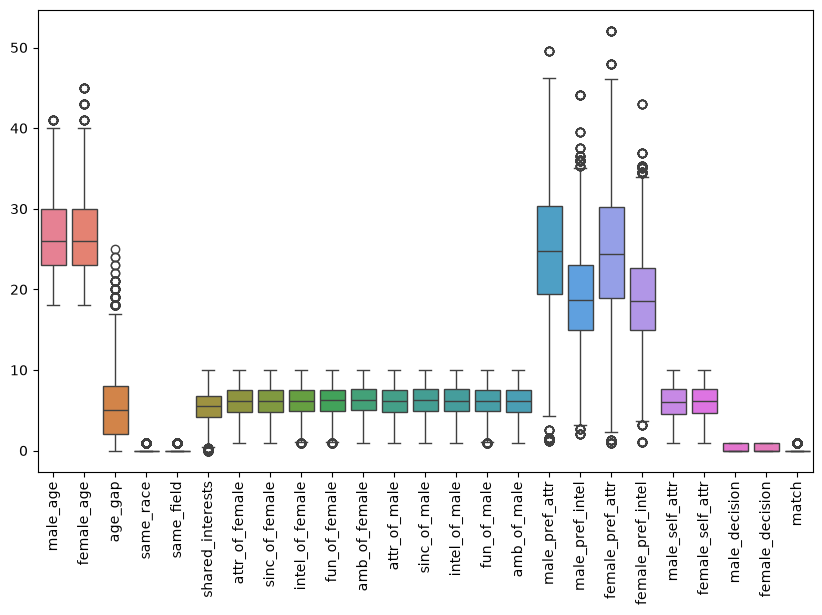

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

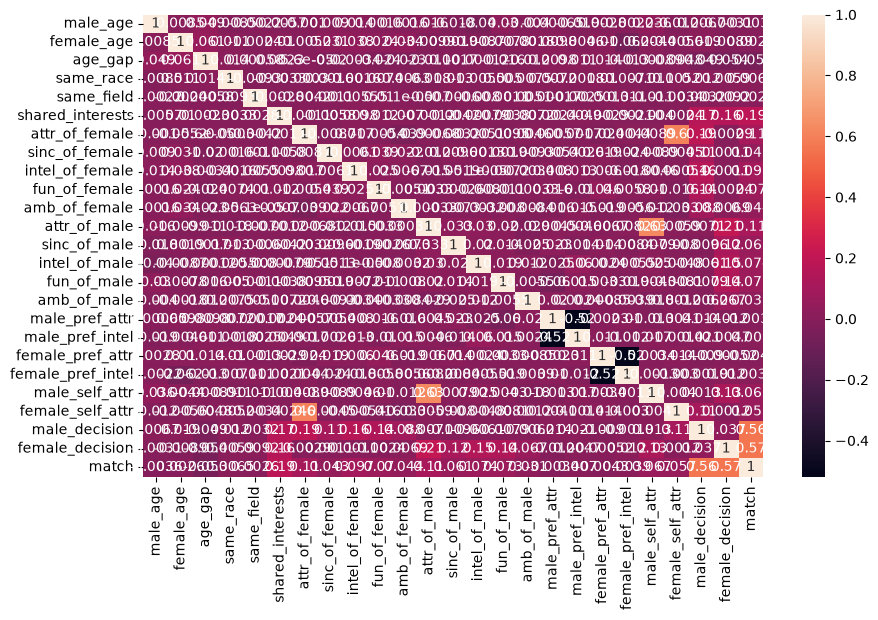

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.xticks(rotation=90)
plt.show()

In [12]:
x=df.drop('match',axis=1)
y=df['match']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
y.value_counts()

match
0    11667
1     2837
Name: count, dtype: int64

In [16]:
num_col=x_train.select_dtypes(exclude='object').columns
num_col

Index(['male_age', 'female_age', 'age_gap', 'same_race', 'same_field',
       'shared_interests', 'attr_of_female', 'sinc_of_female',
       'intel_of_female', 'fun_of_female', 'amb_of_female', 'attr_of_male',
       'sinc_of_male', 'intel_of_male', 'fun_of_male', 'amb_of_male',
       'male_pref_attr', 'male_pref_intel', 'female_pref_attr',
       'female_pref_intel', 'male_self_attr', 'female_self_attr',
       'male_decision', 'female_decision'],
      dtype='object')

In [17]:
cat_col=x_train.select_dtypes(include='object').columns
cat_col

Index(['male_goes_out', 'female_goes_out'], dtype='object')

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer

In [19]:
num_pipeline=Pipeline(
    steps=[('scaler',StandardScaler()),
           ('imput',SimpleImputer(strategy='median'))]
)

In [20]:
mapping = {
    'never': 0,
    'rarely': 1,
    'sometimes': 2,
    'often': 3,
    'very often': 4
}

x_train['male_goes_out'] = x_train['male_goes_out'].map(mapping)
x_train['female_goes_out'] = x_train['female_goes_out'].map(mapping)

In [21]:
cat_pipeline=Pipeline(
    steps=[('encoder',OrdinalEncoder(  handle_unknown='use_encoded_value',
    unknown_value=-1)),
           ('imputer',SimpleImputer(strategy='most_frequent'))]
)
cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when 

In [22]:
x_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11603 entries, 5688 to 7270
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   male_age           11603 non-null  int64  
 1   female_age         11603 non-null  int64  
 2   age_gap            11603 non-null  int64  
 3   same_race          11603 non-null  int64  
 4   same_field         11603 non-null  int64  
 5   shared_interests   11603 non-null  float64
 6   attr_of_female     11603 non-null  float64
 7   sinc_of_female     11603 non-null  float64
 8   intel_of_female    11603 non-null  float64
 9   fun_of_female      11603 non-null  float64
 10  amb_of_female      11603 non-null  float64
 11  attr_of_male       11603 non-null  float64
 12  sinc_of_male       11603 non-null  float64
 13  intel_of_male      11603 non-null  float64
 14  fun_of_male        11603 non-null  float64
 15  amb_of_male        11603 non-null  float64
 16  male_pref_attr     11603 

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
prepocessor=ColumnTransformer(
    transformers=[('numeric',num_pipeline,num_col),('categorical',cat_pipeline,cat_col)])


In [24]:
model_pipeline=Pipeline(
    steps=[('prepocessed',prepocessor),
           ('logisticregression',LogisticRegression())]
)

In [25]:
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepocessed', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: 

In [26]:
model_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepocessed', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['male_age','female_age','age_gap',...,'female_goes_out','male_decision', 'female_decision']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [27]:
prepocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [28]:
x_test_processed=model_pipeline.named_steps['prepocessed'].transform(x_test)

In [29]:
y_pred=model_pipeline.predict(x_test)

In [30]:
train_pred=model_pipeline.predict(x_train)

In [31]:
print(x['male_goes_out'].unique())
print(x['female_goes_out'].unique())

['often' 'sometimes' 'rarely' 'very_often']
['very_often' 'rarely' 'often' 'sometimes']


In [32]:
print('acc_score',accuracy_score(y_test,y_pred))
print('recall_score',recall_score(y_test,y_pred))
print('presion_score',precision_score(y_test,y_pred))
print('f1_score',f1_score(y_test,y_pred))
print('train_pred',accuracy_score(y_train,train_pred))

acc_score 1.0
recall_score 1.0
presion_score 1.0
f1_score 1.0
train_pred 1.0
